In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D

# Функция перевода орбитальных элементов в положение и скорость в гелиоцентрической системе
def orbital_elements_to_state_vectors(a, e, i, Ω, ω, ν, mu):
    i = np.radians(i)
    Ω = np.radians(Ω)
    ω = np.radians(ω)
    ν = np.radians(ν)

    r = a * (1 - e**2) / (1 + e * np.cos(ν))
    x_orb = r * np.cos(ν)
    y_orb = r * np.sin(ν)
    z_orb = 0

    h = np.sqrt(mu * a * (1 - e**2))
    vx_orb = -mu / h * np.sin(ν)
    vy_orb = mu / h * (e + np.cos(ν))
    vz_orb = 0

    cosO, sinO = np.cos(Ω), np.sin(Ω)
    cosi, sini = np.cos(i), np.sin(i)
    cosw, sinw = np.cos(ω), np.sin(ω)

    R = np.array([
        [cosO * cosw - sinO * sinw * cosi, -cosO * sinw - sinO * cosw * cosi, sinO * sini],
        [sinO * cosw + cosO * sinw * cosi, -sinO * sinw + cosO * cosw * cosi, -cosO * sini],
        [sinw * sini, cosw * sini, cosi]
    ])

    r_vec = R @ np.array([x_orb, y_orb, z_orb])
    v_vec = R @ np.array([vx_orb, vy_orb, vz_orb])
    return r_vec, v_vec

# Орбитальные элементы кометы
mu_sun = 1.32712440018e20
au = 1.496e11
a = 3.4630 * au
e = 0.64102
i = 7.0405
O = 50.135573491
w = 12.798250034
v = 0

r_comet, v_comet = orbital_elements_to_state_vectors(a, e, i, O, w, v, mu_sun)

print(r_comet, v_comet)

[8.48606027e+10 1.65408115e+11 5.04954379e+09] [-30279.53672934  15409.67913687   4090.22425241]


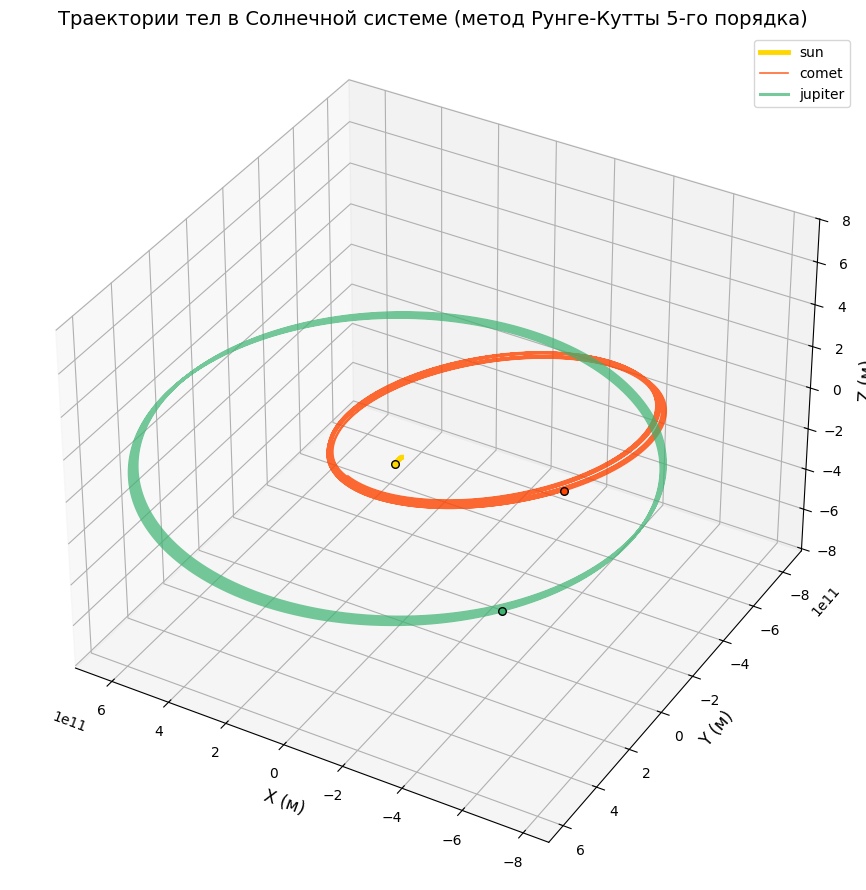

NameError: name 'errors' is not defined

<Figure size 1000x500 with 0 Axes>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D

# Гравитационная постоянная и массы тел
G = 6.67430e-11
masses = {
    "sun": 1.989e30,
    "comet": 1e13,
    "jupiter": 1.898e27,
}

initial_conditions = {
    "sun": np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0]),
    "comet": np.concatenate((r_comet, v_comet)),
    "jupiter": np.array([7.785e11, 0.0, 0.0, 0.0, 13.07e3, 0.0]),
}

def flatten_state(state):
    return np.concatenate([state[k] for k in state])

def unflatten_state(vec):
    keys = list(initial_conditions.keys())
    return dict(zip(keys, vec.reshape(-1, 6)))

def derivatives(state_vec):
    state = unflatten_state(state_vec)
    names = list(state.keys())

    body1 = state[names[0]]
    body2 = state[names[1]]
    body3 = state[names[2]]

    x1, y1, z1, vx1, vy1, vz1 = body1
    x2, y2, z2, vx2, vy2, vz2 = body2
    x3, y3, z3, vx3, vy3, vz3 = body3

    m1 = masses[names[0]]
    m2 = masses[names[1]]
    m3 = masses[names[2]]

    r12 = max(np.linalg.norm(body2[:3] - body1[:3]), 1e-10)
    r13 = max(np.linalg.norm(body3[:3] - body1[:3]), 1e-10)
    r23 = max(np.linalg.norm(body3[:3] - body2[:3]), 1e-10)

    ax1 = G * m2 * (x2 - x1) / r12**3 + G * m3 * (x3 - x1) / r13**3
    ay1 = G * m2 * (y2 - y1) / r12**3 + G * m3 * (y3 - y1) / r13**3
    az1 = G * m2 * (z2 - z1) / r12**3 + G * m3 * (z3 - z1) / r13**3

    ax2 = G * m1 * (x1 - x2) / r12**3 + G * m3 * (x3 - x2) / r23**3
    ay2 = G * m1 * (y1 - y2) / r12**3 + G * m3 * (y3 - y2) / r23**3
    az2 = G * m1 * (z1 - z2) / r12**3 + G * m3 * (z3 - z2) / r23**3

    ax3 = G * m1 * (x1 - x3) / r13**3 + G * m2 * (x2 - x3) / r23**3
    ay3 = G * m1 * (y1 - y3) / r13**3 + G * m2 * (y2 - y3) / r23**3
    az3 = G * m1 * (z1 - z3) / r13**3 + G * m2 * (z2 - z3) / r23**3

    return np.concatenate([
        [vx1, vy1, vz1, ax1, ay1, az1],
        [vx2, vy2, vz2, ax2, ay2, az2],
        [vx3, vy3, vz3, ax3, ay3, az3],
    ])

def rk5_step(state_vec, dt):
    k1 = dt * derivatives(state_vec)
    k2 = dt * derivatives(state_vec + k1 / 4)
    k3 = dt * derivatives(state_vec + (3 * k1 + k2) / 32)
    k4 = dt * derivatives(state_vec + (1932 * k1 - 7200 * k2 + 7296 * k3) / 2197)
    k5 = dt * derivatives(state_vec + (439 * k1 / 216 - 8 * k2 + 3680 * k3 / 513 - 845 * k4 / 4104))
    k6 = dt * derivatives(state_vec - (8 * k1 / 27) + 2 * k2 - (3544 * k3 / 2565) + (1859 * k4 / 4104) - (11 * k5 / 40))
    return state_vec + (16 * k1 / 135 + 6656 * k3 / 12825 + 28561 * k4 / 56430 - 9 * k5 / 50 + 2 * k6 / 55)

def simulate_vec(initial_state, dt, steps):
    state_vec = flatten_state(initial_state)
    keys = list(initial_state.keys())
    trajectory = {k: [] for k in keys}
    full_states = {k: [] for k in keys}
    local_errors = np.zeros(steps)
    global_errors = np.zeros(steps)

    for step in range(steps):
        s_dict = unflatten_state(state_vec)
        for k in keys:
            trajectory[k].append(s_dict[k][:3].copy())
            full_states[k].append(s_dict[k].copy())  # сохраняем и скорости

        s1 = rk5_step(state_vec, dt)
        s2_half = rk5_step(rk5_step(state_vec, dt / 2), dt / 2)

        err = np.linalg.norm(s2_half - s1)
        local_errors[step] = err
        global_errors[step] = global_errors[step - 1] + err if step > 0 else err

        state_vec = s1

    return trajectory, local_errors.tolist(), global_errors.tolist(), full_states

# Параметры симуляции
dt = 2 * 3600  # шаг 2 часа
T = 100 * 365.25 * 24 * 3600  # 100 лет
steps = int(T // dt)

trajectory, local_errors, global_errors, full_states = simulate_vec(initial_conditions, dt, steps)

# Таблица по ошибкам
dfer = pd.DataFrame({
    "i": list(range(1, steps + 1)),
    "local_error": local_errors,
    "global_error": global_errors
})

# === Улучшенная 3D визуализация ===
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

colors = {
    "sun": 'gold',
    "jupiter": 'mediumseagreen',
    "comet": 'orangered'
}
alphas = {
    "sun": 1.0,
    "jupiter": 0.7,
    "comet": 0.8
}
widths = {
    "sun": 3.5,
    "jupiter": 2.2,
    "comet": 1.2
}

for name, coords in trajectory.items():
    coords = np.array(coords)
    ax.plot(coords[:, 0], coords[:, 1], coords[:, 2],
            label=name,
            color=colors.get(name, 'gray'),
            linewidth=widths.get(name, 1.0),
            alpha=alphas.get(name, 1.0))
    ax.scatter(coords[-1, 0], coords[-1, 1], coords[-1, 2],
               s=30, color=colors.get(name, 'gray'), edgecolor='k')

ax.set_xlabel('X (м)', fontsize=12)
ax.set_ylabel('Y (м)', fontsize=12)
ax.set_zlabel('Z (м)', fontsize=12)
ax.set_title('Траектории тел в Солнечной системе (метод Рунге-Кутты 5-го порядка)', fontsize=14)

# Масштаб и центрирование
all_coords = np.vstack([np.array(coords) for coords in trajectory.values()])
max_range = np.ptp(all_coords, axis=0).max()
mid_x, mid_y, mid_z = np.mean(all_coords, axis=0)
ax.set_xlim(mid_x - max_range / 2, mid_x + max_range / 2)
ax.set_ylim(mid_y - max_range / 2, mid_y + max_range / 2)
ax.set_zlim(mid_z - max_range / 2, mid_z + max_range / 2)

ax.view_init(elev=35, azim=120)
ax.legend()
plt.tight_layout()
plt.show()

# === График ошибки ===
plt.figure(figsize=(10, 5))
plt.plot(np.arange(len(errors)) * dt / (86400 * 365.25), errors, color='purple')
plt.yscale('log')
plt.xlabel("Время (годы)")
plt.ylabel("Оценка ошибки")
plt.title("Погрешность на каждом шаге метода Рунге-Кутты 5-го порядка")
plt.grid(True)
plt.tight_layout()
plt.show()
# === Графики ошибок ===
fig, axs = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axs[0].plot(local_errors, label='Локальная ошибка')
axs[0].set_ylabel('Локальная ошибка')
axs[0].set_yscale('log')
axs[0].legend()
axs[0].grid(True)

axs[1].plot(global_errors, label='Глобальная ошибка', color='red')
axs[1].set_xlabel('Шаг')
axs[1].set_ylabel('Глобальная ошибка')
axs[1].set_yscale('log')
axs[1].legend()
axs[1].grid(True)

fig.suptitle("Погрешности метода Рунге-Кутты 5-го порядка")
plt.tight_layout()
plt.show()

# === Таблицы ошибок и траектории кометы ===
comet_traj = trajectory["comet"]
comet_velocities = [unflatten_state(flatten_state(initial_conditions) + rk5_step(flatten_state(initial_conditions), dt * i))["comet"][3:] for i in range(steps)]


In [3]:

# Таблица по положению и скорости кометы
comet_states = full_states["comet"]
dfw = pd.DataFrame({
    "i": list(range(1, steps + 1)),
    "x": [s[0] for s in comet_states],
    "y": [s[1] for s in comet_states],
    "z": [s[2] for s in comet_states],
    "vx": [s[3] for s in comet_states],
    "vy": [s[4] for s in comet_states],
    "vz": [s[5] for s in comet_states],
})

dfw_formatted = dfw.copy()
for col in ["x", "y", "z", "vx", "vy", "vz"]:
    dfw_formatted[col] = dfw[col].apply(lambda v: f"{v:.2e}")

dfw


,i,x,y,z,vx,vy,vz
0,1,8.486060e+10,1.654081e+11,5.049544e+09,-30279.536729,15409.679137,4090.224252
1,2,8.464256e+10,1.655190e+11,5.078991e+09,-30292.133012,15385.093485,4089.472273
2,3,8.442442e+10,1.656297e+11,5.108434e+09,-30304.696862,15360.491420,4088.715919
3,4,8.420619e+10,1.657402e+11,5.137870e+09,-30317.228241,15335.873020,4087.955195
4,5,8.398787e+10,1.658506e+11,5.167302e+09,-30329.727109,15311.238361,4087.190100
...,...,...,...,...,...,...,...
438295,438296,-5.115735e+11,-6.135347e+10,3.140889e+10,-8216.193981,-13862.503837,-424.437770
438296,438297,-5.116326e+11,-6.145328e+10,3.140583e+10,-8212.778855,-13861.833528,-424.647061
438297,438298,-5.116917e+11,-6.155308e+10,3.140277e+10,-8209.364840,-13861.162849,-424.856240
438298,438299,-5.117508e+11,-6.165288e+10,3.139971e+10,-8205.951937,-13860.491798,-425.065307


In [4]:
df = pd.DataFrame({
    "i": list(range(1, steps + 1)),
    "x": [pos[0] for pos in comet_states],
    "y": [pos[1] for pos in comet_states],
    "z": [pos[2] for pos in comet_states],
    "local_error": local_errors,
    "global_error": global_errors
})

df_formatted = df.copy()
for col in ["x", "y", "z", "local_error", "global_error"]:
    df_formatted[col] = df[col].apply(lambda v: f"{v:.2e}")

df

,i,x,y,z,local_error,global_error
0,1,8.486060e+10,1.654081e+11,5.049544e+09,12928.925833,1.292893e+04
1,2,8.464256e+10,1.655190e+11,5.078991e+09,12928.899461,2.585783e+04
2,3,8.442442e+10,1.656297e+11,5.108434e+09,12928.855402,3.878668e+04
3,4,8.420619e+10,1.657402e+11,5.137870e+09,12928.793702,5.171547e+04
4,5,8.398787e+10,1.658506e+11,5.167302e+09,12928.714335,6.464419e+04
...,...,...,...,...,...,...
438295,438296,-5.115735e+11,-6.135347e+10,3.140889e+10,1784.324395,1.042667e+09
438296,438297,-5.116326e+11,-6.145328e+10,3.140583e+10,1783.887907,1.042669e+09
438297,438298,-5.116917e+11,-6.155308e+10,3.140277e+10,1783.451683,1.042670e+09
438298,438299,-5.117508e+11,-6.165288e+10,3.139971e+10,1783.015758,1.042672e+09


In [5]:
dfer.to_csv("IDZENDINGERROR.csv", index=False)
dfw.to_csv("IDZENDINGCORD.csv", index=False)
df.to_csv("IDZENDING.csv",index=False)

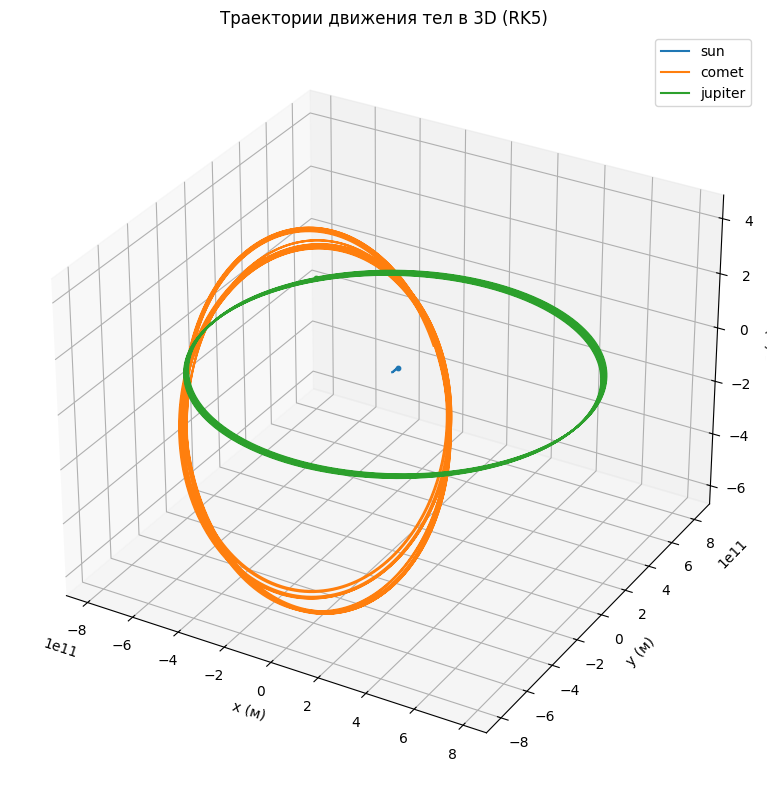

In [13]:

# Визуализация
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
for name, coords in trajectory.items():
    coords = np.array(coords)
    ax.plot(coords[:, 0], coords[:, 1], coords[:, 2], label=name)
    ax.scatter(coords[-1, 0], coords[-1, 1], coords[-1, 2], s=10)
ax.set_xlabel('x (м)')
ax.set_ylabel('y (м)')
ax.set_zlabel('z (м)')
ax.set_title('Траектории движения тел в 3D (RK5)')
ax.legend()
plt.tight_layout()
plt.show()